# BioImage Archive — Biological Image Data Ingestion and Analysis

**BioImage Archive (BIA)** is a public repository hosted by EMBL-EBI for storing and distributing biological images from life sciences research. It sits within the BioStudies ecosystem and accepts submissions of light microscopy, electron microscopy, X-ray tomography, and other bioimaging modalities.

Key data types:
| Data type | Description |
|---|---|
| **Studies** | Experimental submissions with accessions like `S-BIAD\d+` (BIA-specific) or `S-BSST\d+` |
| **Images** | Raw and processed microscopy images (`.tif`, `.czi`, `.nd2`, `.png`, `.zarr`, etc.) |
| **Annotations** | Segmentation masks, bounding boxes, and label files associated with images |
| **Metadata** | Organism, imaging method, sample preparation, biosample, assay details |

Key fields per study:
| Field | Description |
|---|---|
| `accession` | Unique study identifier, e.g. `S-BIAD144` |
| `title` | Human-readable study title |
| `organism` | Source organism(s) |
| `imaging_method` | Microscopy technique (confocal, CLEM, SEM, etc.) |
| `release_date` | Date the study was made public |
| `file_count` | Number of files deposited |
| `file_size_gb` | Total data volume |

**Reference:** Hartley et al. (2022), *Nature Methods*, BioImage Archive — deposition and retrieval of biological images

**API base:** `https://www.ebi.ac.uk/biostudies/api/v1`

# TODO

* [x] **Ingest data**
    * [x] Connect to BioStudies API and confirm access (fetch study S-BIAD144, print title/organism)
    * [x] Search for BioImage Archive studies and page through results (cache to `data/bia_studies.json`)
    * [x] Parse into a Polars DataFrame: accession, title, organism, imaging_method, release_date, file_count, file_size_gb
    * [x] Fetch the file listing for one study of interest to show image file types and sizes
    * [x] Print shape, dtypes, and head of the studies DataFrame
    * [x] Bulk download via FTP (reusing a single connection, byte-size deduplication)
    * [x] Bulk download via Aspera (ascp) for high-bandwidth transfers
* [ ] **Explore and clean**
    * [ ] Summarize study counts by organism, imaging method, and release year
    * [ ] Inspect file type distributions across studies
    * [ ] Handle missing/null fields in study metadata
* [ ] **Analysis**
    * [ ] Identify the most-studied organisms and imaging modalities in BIA
    * [ ] Analyse data volume trends over time (cumulative file size by release date)
    * [ ] Cluster studies by keyword/imaging method profile
* [ ] **Visualization**
    * [ ] Bar chart of submissions by organism and year
    * [ ] Heatmap of imaging method × organism usage
    * [ ] File type distribution for a study of interest
* [ ] **Statistical analysis**
    * [ ] Discuss image quality metrics and their statistical basis
    * [ ] Explain multiple hypothesis correction when comparing image-derived phenotypes at scale

In [1]:
import re
import json
import time
from ftplib import FTP, error_perm
from pathlib import Path

import requests
import polars as pl

## 1. Ingest Data

### 1.1 Connect to BioStudies API and Confirm Access

In [2]:
BIA_BASE = "https://www.ebi.ac.uk/biostudies/api/v1"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def bia_get(endpoint: str, params: dict = None, headers: dict = None) -> requests.Response:
    """
    Send a GET request to the BioStudies/BioImage Archive REST API.

    Parameters
    ----------
    endpoint : str
        API path relative to BIA_BASE (e.g. "studies/S-BIAD144").
    params : dict, optional
        Query parameters appended to the URL.
    headers : dict, optional
        Extra HTTP headers; ``Accept: application/json`` is always added.

    Returns
    -------
    requests.Response
        Raw response object; caller is responsible for parsing.
    """
    url = f"{BIA_BASE}/{endpoint}"
    hdrs = {"Accept": "application/json"}
    if headers:
        hdrs.update(headers)
    resp = requests.get(url, params=params or {}, headers=hdrs, timeout=30)
    resp.raise_for_status()
    return resp

def find_attr(node: dict, name: str) -> str | None:
    """
    Recursively search a BioStudies study record for an attribute ``name``.

    Top-level attributes live under ``attributes``, but richer fields such as
    ``Organism`` and ``Imaging method`` are usually nested inside the study
    ``section`` tree under ``subsections`` (e.g. a Samples/Biosample block).
    This helper walks the tree so callers do not need to know the exact path.
    """
    for a in node.get("attributes", []) or []:
        if a.get("name", "").lower() == name.lower():
            return a.get("value")
    if isinstance(node.get("section"), dict):
        found = find_attr(node["section"], name)
        if found:
            return found
    for sub in node.get("subsections", []) or []:
        if isinstance(sub, dict):
            found = find_attr(sub, name)
            if found:
                return found
    return None

# Connectivity check: fetch a well-known BIA study
sample = bia_get("studies/S-BIAD144").json()
print(f"Accession : {sample.get('accno')}")
print(f"Title     : {find_attr(sample, 'Title')}")
print(f"Organism  : {find_attr(sample, 'Organism')}")
print(f"ReleaseDt : {find_attr(sample, 'ReleaseDate')}")

Accession : S-BIAD144
Title     : The glucosylceramide synthase inhibitor PDMP causes lyso-somal lipid accumulation and mTOR inactivation
Organism  : Homo sapiens (human)
ReleaseDt : 2021-05-31


### 1.2 Search for BioImage Archive Studies and Page Through Results

In [ ]:
STUDIES_CACHE = DATA_DIR / "bia_studies.json"
PAGE_SIZE = 100  # maximum page size the BioStudies search endpoint accepts

def fetch_all_bia_studies(cache_path: Path = STUDIES_CACHE) -> list[dict]:
    """
    Fetch all public BioImage Archive studies via the collection-scoped
    ``/BioImages/search`` endpoint, paging until exhausted.

    The collection filter is important — a free-text ``/search?query=BioImage``
    returns hundreds of PubMed Central cross-references that merely mention
    "BioImage" in abstracts, whereas ``/BioImages/search`` restricts to actual
    BIA submissions (``S-BIAD`` / ``S-BSST`` accessions).  Results are cached
    to disk so subsequent runs load instantly without hitting the API.

    Parameters
    ----------
    cache_path : Path
        File path used to read/write the JSON cache.

    Returns
    -------
    list[dict]
        One dict per study as returned by the BioStudies search API.
    """
    if cache_path.exists():
        print(f"Loading from cache: {cache_path}")
        return json.loads(cache_path.read_text())

    all_studies = []
    page = 1  # BioStudies search is 1-indexed
    while True:
        resp = bia_get(
            "BioImages/search",   # collection-scoped: BIA submissions only
            params={
                "type":     "study",
                "page":     page,
                "pageSize": PAGE_SIZE,
            },
        )
        data = resp.json()
        batch = data.get("hits", [])
        if not batch:
            break  # no more results

        all_studies.extend(batch)
        total = data.get("totalHits", "?")
        print(f"  Page {page:>4} — {len(all_studies):>6} / {total} studies", end="\r")
        page += 1
        time.sleep(0.3)  # polite delay between paginated calls

    print(f"\nDone. Fetched {len(all_studies)} studies.")
    cache_path.write_text(json.dumps(all_studies))   # persist to disk
    return all_studies

# Auto-invalidate any stale cache left by the earlier free-text search
# (those were dominated by S-EPMC PubMed entries, not real BIA submissions)
if STUDIES_CACHE.exists():
    _cached = json.loads(STUDIES_CACHE.read_text())
    _first = _cached[0].get("accession", "") if _cached else ""
    if not _first.startswith(("S-BIAD", "S-BSST")):
        print(f"Stale cache detected (first accession={_first!r}) — refreshing")
        STUDIES_CACHE.unlink()

studies_raw = fetch_all_bia_studies()
print(f"Total studies cached: {len(studies_raw)}")

Stale cache detected (first accession='S-EPMC12265592') — refreshing


### 1.3 Parse into a Polars DataFrame

In [ ]:
def flatten_study(s: dict) -> dict:
    """
    Flatten a BioStudies search-hit dict into a row-friendly format.

    The ``/BioImages/search`` endpoint returns scalar fields at the top level
    (``accession``, ``title``, ``author``, ``release_date``, ``files`` count,
    ``views``, ``content`` preview).  Richer metadata such as ``organism`` or
    ``imaging_method`` lives only in the per-study record at
    ``/studies/<accno>`` — we leave those as nulls here and populate them
    lazily for a subset in a later analysis cell.

    Parameters
    ----------
    s : dict
        Raw study record from the BioStudies ``/BioImages/search`` endpoint.

    Returns
    -------
    dict
        Flat dict with scalar values ready for a Polars DataFrame row.
    """
    return {
        "accession":     s.get("accession") or s.get("accno"),
        "title":         s.get("title"),
        "author":        s.get("author"),
        "release_date":  s.get("release_date"),
        "file_count":    s.get("files"),
        "views":         s.get("views"),
        "organism":       None,   # populated by per-study enrichment
        "imaging_method": None,   # populated by per-study enrichment
    }

rows = [flatten_study(s) for s in studies_raw]
studies = pl.DataFrame(rows)

# release_date arrives as an ISO-8601 string (e.g. "2023-03-22") — parse to Date
if studies["release_date"].dtype == pl.Utf8:
    studies = studies.with_columns(
        pl.col("release_date").str.to_date(format="%Y-%m-%d", strict=False)
    )

# Cast count column to a compact integer type
studies = studies.with_columns(
    pl.col("file_count").cast(pl.Int32, strict=False),
)

print(f"Shape  : {studies.shape}")
print(f"Memory : {studies.estimated_size('kb'):.1f} KB")
print()
print(studies.dtypes)
print()
studies.head(10)

### 1.4 Fetch File Listing for a Study of Interest

In [ ]:
FTP_HOST = "ftp.ebi.ac.uk"
FTP_BASE = "/biostudies"

def bia_ftp_path(accession: str) -> str:
    """
    Compute the BioImage Archive FTP sub-path for a study accession.

    The BIA FTP layout groups studies by the *last three digits* of the
    numeric suffix of the accession (see
    https://www.ebi.ac.uk/bioimage-archive/help-download/).  Examples:

    * ``S-BIAD144``  → ``S-BIAD/144/S-BIAD144/Files``
    * ``S-BIAD570``  → ``S-BIAD/570/S-BIAD570/Files``
    * ``S-BIAD2119`` → ``S-BIAD/119/S-BIAD2119/Files``  (last 3 digits of 2119)
    """
    m = re.match(r"(S-[A-Z]+)(\d+)", accession)
    if not m:
        raise ValueError(f"Invalid BIA accession: {accession!r}")
    prefix, num = m.group(1), m.group(2)
    subdir = num[-3:] if len(num) >= 3 else num.zfill(3)
    return f"{prefix}/{subdir}/{accession}/Files"

def open_bia_ftp(accession: str) -> tuple[FTP, str]:
    """
    Open an anonymous FTP connection to ``ftp.ebi.ac.uk`` and ``cd`` into
    the study's ``Files/`` directory.

    BIA data lives in one of two storage modes — ``fire`` or ``nfs`` — and
    a given study only exists under one of them.  We try ``fire`` first
    (the newer / more common mode) and fall back to ``nfs`` on a 550 error.

    Returns
    -------
    (ftp, mode) : tuple[FTP, str]
        A logged-in FTP connection already positioned in Files/ and the
        mode that succeeded.  Caller is responsible for ``ftp.quit()``.
    """
    sub = bia_ftp_path(accession)
    ftp = FTP(FTP_HOST, timeout=60)
    ftp.login()  # anonymous
    for mode in ("fire", "nfs"):
        try:
            ftp.cwd(f"{FTP_BASE}/{mode}/{sub}")
            return ftp, mode
        except error_perm:
            continue
    ftp.quit()
    raise FileNotFoundError(
        f"No FTP Files/ directory for {accession} under fire or nfs modes"
    )

def list_study_files(accession: str) -> pl.DataFrame:
    """
    List the top-level contents of a BIA study's ``Files/`` directory
    over anonymous FTP and return a Polars DataFrame.
    """
    ftp, mode = open_bia_ftp(accession)
    try:
        lines: list[str] = []
        ftp.retrlines("LIST", lines.append)
    finally:
        ftp.quit()

    rows = []
    for line in lines:
        # Unix-style LIST line:
        # "drwxr-xr-x  2 ftp ftp  4096 Mar 22  2023 experiments"
        parts = line.split(maxsplit=8)
        if len(parts) < 9:
            continue
        perms, _links, _owner, _group, size = parts[:5]
        name = parts[8]
        rows.append({
            "name":       name,
            "kind":       "dir" if perms.startswith("d") else "file",
            "size_bytes": int(size),
            "size_mb":    round(int(size) / 1e6, 3),
            "extension":  Path(name).suffix.lower() or "(none)",
        })
    return pl.DataFrame(rows).with_columns(mode=pl.lit(mode))

def download_bia_file(accession: str, filename: str, dest_dir: Path) -> Path:
    """
    Download ``filename`` from the given study's ``Files/`` directory over
    anonymous FTP and save it under ``dest_dir``.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    out = dest_dir / filename

    ftp, mode = open_bia_ftp(accession)
    try:
        with out.open("wb") as fh:
            ftp.retrbinary(f"RETR {filename}", fh.write)
    finally:
        ftp.quit()
    print(f"  downloaded ({mode}) → {out}  [{out.stat().st_size:,} bytes]")
    return out

# ---- Test: list and download one small file from S-BIAD144 -----------------
FOCUS_STUDY = "S-BIAD144"

listing = list_study_files(FOCUS_STUDY)
print(f"Files in {FOCUS_STUDY}/Files/: {len(listing)} top-level entries\n")
print(listing)

# Summarise by extension (top-level only — directories show up as "(none)")
summary = (
    listing.filter(pl.col("kind") == "file")
           .group_by("extension")
           .agg(
               pl.len().alias("count"),
               (pl.col("size_bytes").sum() / 1e6).round(2).alias("total_mb"),
           )
           .sort("total_mb", descending=True)
)
print("\nFile extensions (top-level files only):")
print(summary)

# Proof-of-concept: download the smallest top-level file
smallest = (
    listing.filter(pl.col("kind") == "file")
           .sort("size_bytes")
           .head(1)
)
test_name = smallest["name"][0]
print(f"\nDownloading smallest file: {test_name!r}")

dest = DATA_DIR / FOCUS_STUDY
out_path = download_bia_file(FOCUS_STUDY, test_name, dest)
print(f"Local path: {out_path}")

In [9]:
# Download everything in experiments/ for S-BIAD144 (~430 MB, 223 .czi files).
# Idempotent: files already present with the correct byte size are skipped.
EXPERIMENTS_DIR = DATA_DIR / FOCUS_STUDY / "experiments"
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

# Open one FTP connection and reuse it for the whole batch (avoids the ~1 s
# handshake cost per file that a fresh download_bia_file() call would incur).
ftp, mode = open_bia_ftp(FOCUS_STUDY)
try:
    ftp.cwd("experiments")   # relative to the Files/ dir we are already in

    # List remote files with sizes so we can report progress and dedupe
    raw_lines: list[str] = []
    ftp.retrlines("LIST", raw_lines.append)

    remote_files: list[tuple[str, int]] = []
    for line in raw_lines:
        parts = line.split(maxsplit=8)
        if len(parts) < 9 or parts[0].startswith("d"):
            continue                # skip malformed lines and subdirectories
        remote_files.append((parts[8], int(parts[4])))

    total_bytes = sum(sz for _, sz in remote_files)
    print(f"{FOCUS_STUDY}/experiments: {len(remote_files)} files, "
          f"{total_bytes / 1e6:.1f} MB total (via {mode} mode)")

    downloaded = skipped = 0
    bytes_done = 0
    for idx, (name, size) in enumerate(remote_files, start=1):
        out = EXPERIMENTS_DIR / name
        # Resume-safe: skip files already present at the expected size
        if out.exists() and out.stat().st_size == size:
            skipped += 1
            bytes_done += size
            continue

        with out.open("wb") as fh:
            ftp.retrbinary(f"RETR {name}", fh.write)
        downloaded += 1
        bytes_done += size
        # In-place progress ticker (don't spam the output with 223 lines)
        print(
            f"  [{idx:>3}/{len(remote_files)}] "
            f"{bytes_done / 1e6:>6.1f} / {total_bytes / 1e6:.1f} MB "
            f"— {name}",
            end="\r",
        )
finally:
    ftp.quit()

print()  # newline after the \r-updated progress line
print(f"Done — downloaded {downloaded}, skipped {skipped} "
      f"(already present) → {EXPERIMENTS_DIR}")

S-BIAD144/experiments: 223 files, 432.6 MB total (via fire mode)


error_temp: 426 Failure writing network stream.

### 1.5 Bulk Download via Aspera

[Aspera FASP](https://www.ibm.com/products/aspera) is a UDP-based transfer protocol that saturates high-bandwidth links far more efficiently than FTP or HTTP — EBI benchmarks routinely exceed 500 Mbit/s vs. ~10–30 Mbit/s for anonymous FTP.  The BioImage Archive exposes its entire file store via an anonymous FASP endpoint (`fasp-public@fasp.ebi.ac.uk`), making Aspera the recommended method for bulk study downloads.

**Prerequisites:**

1. Install the [IBM Aspera Transfer SDK](https://www.ibm.com/products/aspera/downloads) — this places `ascp` on your PATH.
2. The SDK ships with a bypass private key (`aspera_bypass_pk.pem`) that enables anonymous EBI access; no account is needed.

**FASP endpoint:**

| Parameter | Value |
|---|---|
| Server | `fasp.ebi.ac.uk` |
| User | `fasp-public` |
| Port | `33001` |
| Auth key | `aspera_bypass_pk.pem` (bundled with SDK) |

The remote path mirrors the FTP layout — it is resolved automatically from the BioStudies `/info` API so you never need to hard-code it.

In [ ]:
import os
import platform
import stat
import tarfile
import urllib.request
import shutil
import subprocess

ASPERA_HOST = "fasp.ebi.ac.uk"
ASPERA_USER = "fasp-public"
ASPERA_PORT = 33001
ASPERA_RATE = "300M"

KEYS_DIR = Path("keys")
BIN_DIR  = Path("bin")

# IBM Aspera Connect is publicly downloadable from IBM's CDN without an
# account.  The Connect client bundles the same ascp binary as the full SDK.
# On Linux the tarball contains a single self-extracting .sh installer that
# places everything under ~/.aspera/connect/.
_ASPERA_VERSION = "4.2.12.781"
_ASPERA_CONNECT_INSTALL_DIR = Path.home() / ".aspera" / "connect"
_ASPERA_CONNECT_URLS: dict[tuple[str, str], dict[str, str]] = {
    ("Linux", "x86_64"): {
        "url": (
            "https://d3gcli72yxqn2z.cloudfront.net/connect/v4/bin/"
            f"ibm-aspera-connect_{_ASPERA_VERSION}_linux_x86_64.tar.gz"
        ),
        "installer": f"ibm-aspera-connect_{_ASPERA_VERSION}_linux_x86_64.sh",
    },
    ("Linux", "aarch64"): {
        "url": (
            "https://d3gcli72yxqn2z.cloudfront.net/connect/v4/bin/"
            f"ibm-aspera-connect_{_ASPERA_VERSION}_linux_aarch64.tar.gz"
        ),
        "installer": f"ibm-aspera-connect_{_ASPERA_VERSION}_linux_aarch64.sh",
    },
}

# Standard SDK install locations searched before attempting any installation.
_ASPERA_KEY_CANDIDATES: list[Path] = [
    _ASPERA_CONNECT_INSTALL_DIR / "etc" / "asperaweb_id_dsa.openssh",
    Path.home() / ".aspera" / "ascli" / "sdk" / "aspera_bypass_pk.pem",
    Path("/opt/aspera/key/aspera_bypass_pk.pem"),
    Path("/usr/local/aspera/key/aspera_bypass_pk.pem"),
]


# ── Key helpers ───────────────────────────────────────────────────────────────

def _generate_rsa_key_cryptography(dest: Path) -> None:
    from cryptography.hazmat.primitives import serialization
    from cryptography.hazmat.primitives.asymmetric import rsa

    key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
    pem = key.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.TraditionalOpenSSL,
        encryption_algorithm=serialization.NoEncryption(),
    )
    dest.write_bytes(pem)
    dest.chmod(0o600)


def _generate_rsa_key_sshkeygen(dest: Path) -> None:
    subprocess.run(
        ["ssh-keygen", "-t", "rsa", "-b", "2048", "-N", "", "-f", str(dest)],
        check=True, capture_output=True,
    )
    pub = dest.with_suffix(dest.suffix + ".pub")
    if pub.exists():
        pub.unlink()
    dest.chmod(0o600)


def get_or_create_aspera_key() -> Path:
    """
    Return a path to an Aspera-compatible RSA private key, generating one
    in ``keys/`` if none is found in standard SDK install locations.

    EBI's ``fasp-public`` endpoint performs an SSH handshake but does not
    restrict which key identity is used, so a freshly generated RSA-2048 key
    works for anonymous access.
    """
    for candidate in _ASPERA_KEY_CANDIDATES:
        if candidate.exists():
            print(f"Using existing Aspera key: {candidate}")
            return candidate

    project_key = KEYS_DIR / "aspera_bypass_pk.pem"
    if project_key.exists():
        print(f"Using existing generated key: {project_key}")
        return project_key

    KEYS_DIR.mkdir(parents=True, exist_ok=True)
    print(f"No Aspera key found — generating RSA-2048 key → {project_key}")
    try:
        _generate_rsa_key_cryptography(project_key)
        print("  Generated via cryptography library.")
    except ImportError:
        if shutil.which("ssh-keygen") is None:
            raise RuntimeError(
                "Cannot generate a key: install cryptography or openssh.\n"
                "  pip install cryptography"
            )
        _generate_rsa_key_sshkeygen(project_key)
        print("  Generated via ssh-keygen.")
    return project_key


# ── ascp install helpers ──────────────────────────────────────────────────────

def find_ascp() -> str | None:
    """Return the ascp binary path from PATH or the Connect install dir."""
    path = shutil.which("ascp")
    if path:
        return path
    # Also check where the Connect installer puts it
    bundled = _ASPERA_CONNECT_INSTALL_DIR / "bin" / "ascp"
    return str(bundled) if bundled.exists() else None


def _try_conda_install() -> str | None:
    """
    Install ascp via conda or mamba using the hcc or bioconda channel.

    Returns the ascp path on success, None if conda/mamba is unavailable or
    the install fails.
    """
    for mgr in ("mamba", "conda"):
        if shutil.which(mgr) is None:
            continue
        for pkg, channel in [("aspera-cli", "hcc"), ("aspera-client", "bioconda")]:
            print(f"Trying: {mgr} install -c {channel} {pkg}")
            result = subprocess.run(
                [mgr, "install", "-y", "-c", channel, pkg],
                capture_output=True, text=True,
            )
            if result.returncode == 0:
                path = shutil.which("ascp")
                if path:
                    return path
    return None


def _try_direct_install() -> str | None:
    """
    Download IBM Aspera Connect from IBM's public CDN and run its installer.

    Supported platforms: Linux x86_64 and aarch64.  The installer places
    ``ascp`` at ``~/.aspera/connect/bin/ascp``.  Returns the path on success
    or None if the platform is unsupported / the download fails.
    """
    system  = platform.system()
    machine = platform.machine()
    info    = _ASPERA_CONNECT_URLS.get((system, machine))

    if info is None:
        print(
            f"Direct download not supported for {system}/{machine}.\n"
            "Download manually from https://www.ibm.com/products/aspera/downloads"
        )
        return None

    BIN_DIR.mkdir(parents=True, exist_ok=True)
    archive = BIN_DIR / info["url"].split("/")[-1]

    print(f"Downloading IBM Aspera Connect {_ASPERA_VERSION} ({system}/{machine})…")
    try:
        urllib.request.urlretrieve(info["url"], archive)
    except Exception as exc:
        print(f"Download failed: {exc}")
        return None
    print(f"  Saved → {archive}")

    # The tar.gz contains a single self-extracting shell script.
    installer = BIN_DIR / info["installer"]
    with tarfile.open(archive) as tf:
        member = tf.getmember(info["installer"])
        tf.extract(member, BIN_DIR)
    installer.chmod(installer.stat().st_mode | stat.S_IEXEC)

    print("Running installer (installs to ~/.aspera/connect/)…")
    result = subprocess.run(
        ["bash", str(installer)],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"Installer failed:\n{result.stderr}")
        return None

    ascp = _ASPERA_CONNECT_INSTALL_DIR / "bin" / "ascp"
    return str(ascp) if ascp.exists() else None


def ensure_ascp(ascp_path: str | None = None) -> str:
    """
    Return a usable ``ascp`` binary path, installing Aspera if necessary.

    Parameters
    ----------
    ascp_path : str, optional
        Explicit path supplied by the caller; returned immediately if given.

    Returns
    -------
    str
        Absolute path to the ``ascp`` binary.

    Raises
    ------
    RuntimeError
        If all installation methods fail.

    Notes
    -----
    Installation is attempted in this order:

    1. **PATH / Connect install dir** — reuses an existing installation.
    2. **conda / mamba** — ``conda install -c hcc aspera-cli`` (preferred in
       Conda environments; the hcc channel ships a pre-built ascp binary).
    3. **Direct CDN download** — downloads the IBM Aspera Connect installer
       from IBM's public CloudFront CDN and runs it (Linux x86_64 / aarch64
       only; no IBM account required).
    """
    if ascp_path:
        return ascp_path

    found = find_ascp()
    if found:
        print(f"Found ascp: {found}")
        return found

    print("ascp not found — attempting automatic installation…\n")

    path = _try_conda_install()
    if path:
        print(f"\nInstalled via conda → {path}")
        return path

    path = _try_direct_install()
    if path:
        print(f"\nInstalled via direct download → {path}")
        return path

    raise RuntimeError(
        "Could not install IBM Aspera ascp automatically.\n\n"
        "Manual options:\n"
        "  conda install -c hcc aspera-cli\n"
        "  conda install -c bioconda aspera-client\n"
        "  # or download from: https://www.ibm.com/products/aspera/downloads"
    )


# ── Path and download helpers ─────────────────────────────────────────────────

def bia_fasp_path(accession: str) -> str:
    """
    Resolve the FASP path for a BIA study via the BioStudies /info endpoint.

    Strips the ``ftp://ftp.ebi.ac.uk`` prefix from the returned ``ftpLink``
    to obtain the identical path served by the FASP host.
    """
    resp = bia_get(f"studies/{accession}/info")
    ftp_link: str = resp.json().get("ftpLink", "")
    if not ftp_link:
        raise ValueError(f"No ftpLink returned by the API for {accession!r}")
    return ftp_link.replace("ftp://ftp.ebi.ac.uk", "")


def aspera_download(
    accession: str,
    dest_dir: Path,
    *,
    ascp_path: str | None = None,
    key_path: Path | None = None,
    rate: str = ASPERA_RATE,
    recursive: bool = True,
    dry_run: bool = False,
) -> list[str]:
    """
    Download a BIA study's Files/ tree via Aspera (ascp).

    ``ascp`` is located (or installed) automatically via ``ensure_ascp()``.
    The private key is located (or generated) automatically via
    ``get_or_create_aspera_key()``.

    Parameters
    ----------
    accession : str
        BIA study accession, e.g. ``"S-BIAD144"``.
    dest_dir : Path
        Local destination directory; created if absent.
    ascp_path : str, optional
        Explicit path to ``ascp``; auto-detected/installed if omitted.
    key_path : Path, optional
        Aspera private key; auto-detected/generated if omitted.
    rate : str
        Peak transfer rate cap passed to ``-l`` (default ``"300M"`` Mbit/s).
    recursive : bool
        Mirror the full ``Files/`` subtree (passes ``-r``).
    dry_run : bool
        Return the command list without executing it.

    Returns
    -------
    list[str]
        The ascp command tokens (executed unless ``dry_run=True``).
    """
    ascp = ensure_ascp(ascp_path)
    key  = key_path or get_or_create_aspera_key()

    remote_path = bia_fasp_path(accession)
    dest_dir.mkdir(parents=True, exist_ok=True)

    cmd: list[str] = [
        str(ascp),
        "-P", str(ASPERA_PORT),
        "-Q",
        "-l", rate,
        "-i", str(key),
    ]
    if recursive:
        cmd.append("-r")
    cmd += [f"{ASPERA_USER}@{ASPERA_HOST}:{remote_path}", str(dest_dir)]

    if dry_run:
        return cmd

    print(f"Starting Aspera transfer: {accession} → {dest_dir}")
    print("Command:", " ".join(cmd))
    result = subprocess.run(cmd, check=True, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    print(f"Transfer complete → {dest_dir}")
    return cmd


# ── Demo: resolve key + show command ─────────────────────────────────────────
fasp_path = bia_fasp_path(FOCUS_STUDY)
print(f"Remote FASP path for {FOCUS_STUDY}: {fasp_path}\n")

key = get_or_create_aspera_key()
print(f"Key path: {key}\n")

try:
    cmd = aspera_download(
        FOCUS_STUDY,
        DATA_DIR / f"{FOCUS_STUDY}_aspera",
        key_path=key,
        dry_run=True,
    )
    print("Ascp command (dry run):")
    print("  " + " \\\n    ".join(cmd))
except RuntimeError as exc:
    print(exc)

### 1.6 Unpack CZI Files and Extract Basic Image Metadata

The downloaded files are Zeiss [CZI](https://www.zeiss.com/microscopy/int/products/microscope-software/zen/czi.html)
containers — a ZIP-like structure wrapping one or more image sub-blocks plus an
XML metadata payload.  Each sub-block stores raw pixels; the XML carries the
acquisition context (pixel size, channels, objective, timestamps, etc.).  We
read them with the pure-Python `czifile` library (no native build needed,
unlike `aicspylibczi` / `pylibCZIrw` which require `cmake`).

In [10]:
import xml.etree.ElementTree as ET

import czifile
import numpy as np

def inspect_czi(path: Path) -> dict:
    """
    Open a single CZI file and extract a compact per-file summary.

    The CZI XML payload is large (~400 KB for these files) but we only pull a
    handful of fields: image shape/dtype, physical pixel size, channel
    labels + fluorophores, objective, and acquisition timestamp.  Pixel data
    is loaded via ``asarray`` only to capture shape + dtype + intensity range;
    the numpy array is discarded immediately so memory usage stays flat.

    Corrupt or truncated files (e.g. an interrupted download) can raise when
    ``czifile`` walks the sub-block directory — we catch those, record the
    error, and return a row with null metadata fields so one bad file doesn't
    derail the batch.
    """
    base = {"file": path.name, "size_mb": round(path.stat().st_size / 1e6, 3)}
    try:
        with czifile.CziFile(path) as czi:
            arr = czi.asarray()                   # fully decode the sub-blocks
            md_root = ET.fromstring(czi.metadata())
    except Exception as e:
        return {**base, "error": f"{type(e).__name__}: {e}"}

    def text(xpath: str) -> str | None:
        el = md_root.find(xpath)
        return el.text if el is not None and el.text else None

    # Physical pixel size — CZI stores distances in metres, convert to µm
    scales: dict[str, float] = {}
    for d in md_root.iterfind(".//Scaling/Items/Distance"):
        v = d.findtext("Value")
        if v is not None:
            scales[d.get("Id", "?")] = float(v) * 1e6  # m → µm

    # Channels: collect name + fluorophore
    channels: list[str] = []
    for ch in md_root.iterfind(".//Information/Image/Dimensions/Channels/Channel"):
        nm = ch.get("Name") or ch.findtext("Fluor") or ch.get("Id") or "?"
        fl = ch.findtext("Fluor")
        channels.append(f"{nm} ({fl})" if fl and fl not in nm else nm)

    # Pixel intensity stats — sanity check for "is there signal?"
    p1, p99 = np.percentile(arr, [1, 99])

    return {
        **base,
        "shape":         str(tuple(arr.shape)),    # e.g. "(2, 512, 512)"
        "dtype":         str(arr.dtype),
        "n_channels":    len(channels),
        "channels":      " | ".join(channels) if channels else None,
        "px_um_x":       round(scales.get("X"), 4) if "X" in scales else None,
        "px_um_y":       round(scales.get("Y"), 4) if "Y" in scales else None,
        "px_um_z":       round(scales.get("Z"), 4) if "Z" in scales else None,
        "intensity_p1":  float(p1),
        "intensity_p99": float(p99),
        "created":       text(".//Information/Document/CreationDate"),
        "objective":     text(".//Instrument/Objectives/Objective/Manufacturer/Model"),
        "magnification": text(".//Instrument/Objectives/Objective/NominalMagnification"),
        "na":            text(".//Instrument/Objectives/Objective/LensNA"),
        "error":         None,
    }

czi_files = sorted(EXPERIMENTS_DIR.glob("*.czi"))
print(f"Inspecting {len(czi_files)} CZI files in {EXPERIMENTS_DIR}")

summaries = [inspect_czi(p) for p in czi_files]
czi_info = pl.DataFrame(summaries).with_columns(
    # CZI timestamps carry a timezone offset (e.g. '+02:00'); normalise to UTC
    pl.col("created").str.to_datetime(
        format="%Y-%m-%dT%H:%M:%S%.f%z", strict=False, time_zone="UTC",
    ),
)

# Flag any failures up front so truncated downloads don't silently hide
failed = czi_info.filter(pl.col("error").is_not_null())
if len(failed) > 0:
    print(f"\n{len(failed)} file(s) failed to parse (likely truncated):")
    print(failed.select(["file", "size_mb", "error"]))
    print("   rerun the download cell — byte-size mismatch will re-fetch them.\n")

print(f"Shape of summary table: {czi_info.shape}")
czi_info.select([
    "file", "shape", "dtype", "n_channels", "px_um_x", "px_um_y",
    "intensity_p1", "intensity_p99",
])

Inspecting 23 CZI files in data/S-BIAD144/experiments

1 file(s) failed to parse (likely truncated):
shape: (1, 3)
┌──────────────────────────────┬─────────┬─────────────────────────────────┐
│ file                         ┆ size_mb ┆ error                           │
│ ---                          ┆ ---     ┆ ---                             │
│ str                          ┆ f64     ┆ str                             │
╞══════════════════════════════╪═════════╪═════════════════════════════════╡
│ experimentB_02_PDMP_0min.czi ┆ 0.014   ┆ CziSegmentNotFoundError: faile… │
└──────────────────────────────┴─────────┴─────────────────────────────────┘
   rerun the download cell — byte-size mismatch will re-fetch them.

Shape of summary table: (23, 16)


file,shape,dtype,n_channels,px_um_x,px_um_y,intensity_p1,intensity_p99
str,str,str,i64,f64,f64,f64,f64
"""experimentA_01_WT_PDMP.czi""","""(2, 512, 512)""","""uint8""",2,0.2201,0.2201,0.0,211.0
"""experimentA_02_WT_PDMP.czi""","""(2, 512, 512)""","""uint8""",2,0.2201,0.2201,0.0,186.0
"""experimentA_03_WT_PDMP.czi""","""(2, 512, 512)""","""uint8""",2,0.2476,0.2476,0.0,243.0
"""experimentA_04_WT_PDMP.czi""","""(2, 512, 512)""","""uint8""",2,0.2476,0.2476,0.0,255.0
"""experimentA_05_WT_PDMP.czi""","""(2, 512, 512)""","""uint8""",2,0.2476,0.2476,0.0,218.0
…,…,…,…,…,…,…,…
"""experimentA_19_SGPL1_Miglustat…","""(2, 512, 512)""","""uint8""",2,0.3961,0.3961,0.0,218.0
"""experimentA_20_SGPL1_Miglustat…","""(2, 512, 512)""","""uint8""",2,0.3961,0.3961,0.0,185.0
"""experimentA_21_SGPL1_Miglustat…","""(2, 512, 512)""","""uint8""",2,0.3961,0.3961,0.0,177.0


In [11]:
# Aggregate view: what's actually in this batch of images?
ok = czi_info.filter(pl.col("error").is_null())

print("=== Aggregate across inspected files ===")
print(f"Parsed OK          : {len(ok)}/{len(czi_info)}")
print(f"Total size on disk : {czi_info['size_mb'].sum():.1f} MB")
print()
print(f"Unique shapes      : {ok['shape'].unique().to_list()}")
print(f"Unique dtypes      : {ok['dtype'].unique().to_list()}")
print(f"Unique channels    : {ok['channels'].unique().to_list()}")
print(f"Unique objectives  : {ok['objective'].unique().to_list()}  (NA={ok['na'].unique().to_list()})")
print(f"px size (µm/px)    : x={ok['px_um_x'].unique().to_list()}  y={ok['px_um_y'].unique().to_list()}")
print(f"Acquisition window : {ok['created'].min()} → {ok['created'].max()}")

# Extract the experimental condition from the filename
# (pattern: experimentA_NN_CELL_TREATMENT.czi)
conditions = (
    ok.with_columns(
        pl.col("file")
          .str.extract(r"experiment[AB]_\d+_([A-Za-z0-9]+_[A-Za-z0-9]+)", 1)
          .alias("condition")
    )
    .group_by("condition")
    .agg(pl.len().alias("n_images"))
    .sort("n_images", descending=True)
)
print("\nImages per experimental condition (cell_treatment):")
print(conditions)

=== Aggregate across inspected files ===
Parsed OK          : 22/23
Total size on disk : 34.9 MB

Unique shapes      : ['(2, 512, 512)']
Unique dtypes      : ['uint8']
Unique channels    : ['AF594-T1 (Alexa Fluor 594) | AF488-T2 (Alexa Fluor 488)', 'AF555-T1 (Alexa Fluor 555) | AF488-T2 (Alexa Fluor 488)']
Unique objectives  : ['Plan-Apochromat 63x/1.40 Oil DIC M27']  (NA=['1.4'])
px size (µm/px)    : x=[0.1801, 0.2201, 0.2476, 0.3301, 0.3961]  y=[0.1801, 0.2201, 0.2476, 0.3301, 0.3961]
Acquisition window : 2019-09-06 09:32:27.475400+00:00 → 2020-05-04 10:57:02.333000+00:00

Images per experimental condition (cell_treatment):
shape: (7, 2)
┌─────────────────┬──────────┐
│ condition       ┆ n_images │
│ ---             ┆ ---      │
│ str             ┆ u32      │
╞═════════════════╪══════════╡
│ WT_PDMP         ┆ 5        │
│ SGPL1_PDMP      ┆ 4        │
│ WT_mock         ┆ 3        │
│ SGPL1_mock      ┆ 3        │
│ WT_Miglustat    ┆ 3        │
│ SGPL1_Miglustat ┆ 3        │
│ PDMP_0min

### 1.7 Visualise One CZI File

Fluorescence microscopy images are raw photon-count arrays whose native
dynamic range rarely fills the 8-bit display space — raw `imshow` typically
looks black.  Standard practice is a per-channel contrast stretch (clip
below the 1st percentile and above the ~99.5th percentile, then rescale to
[0, 1]) which keeps real signal visible while suppressing sensor hot
pixels.  For 2-channel overlays the community convention is **magenta + green**
rather than red + green — the pair is deuteranopia-safe and keeps
colocalisation unambiguous (white = both channels strong).

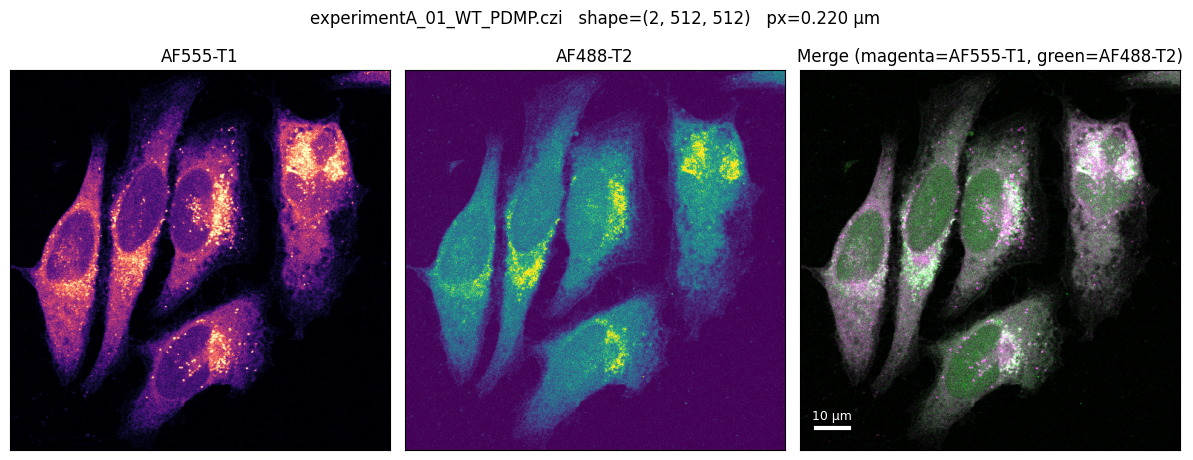

In [12]:
import matplotlib.pyplot as plt

def stretch(img: np.ndarray, lo_pct: float = 1.0, hi_pct: float = 99.5) -> np.ndarray:
    """
    Percentile-based contrast stretch for display.

    Maps ``img[lo_pct]`` → 0 and ``img[hi_pct]`` → 1 (then clips).  Using
    percentiles rather than min/max makes the result robust to sensor hot
    pixels and the small number of saturated pixels common in immuno-
    fluorescence.
    """
    lo, hi = np.percentile(img, [lo_pct, hi_pct])
    return np.clip((img.astype(float) - lo) / max(hi - lo, 1e-9), 0.0, 1.0)

def display_czi(path: Path, scale_bar_um: float = 10.0, figsize=(12, 4.5)) -> None:
    """
    Render one CZI file as three panels: channel 0, channel 1, and a
    magenta/green merge.  Pulls the physical pixel size from the CZI
    metadata so the scale bar is always correct.
    """
    with czifile.CziFile(path) as czi:
        arr = czi.asarray()
        md_root = ET.fromstring(czi.metadata())

    if arr.ndim != 3 or arr.shape[0] < 2:
        raise ValueError(f"Expected a (C>=2, Y, X) stack, got {arr.shape}")
    c0, c1 = stretch(arr[0]), stretch(arr[1])

    # Physical pixel size (µm/px) — CZI stores in metres
    dx_m = md_root.find(".//Scaling/Items/Distance[@Id='X']/Value")
    px_um = float(dx_m.text) * 1e6 if dx_m is not None and dx_m.text else None

    # Channel labels from the metadata, or fall back to generic names
    ch_labels: list[str] = []
    for ch in md_root.iterfind(".//Information/Image/Dimensions/Channels/Channel"):
        ch_labels.append(ch.get("Name") or ch.findtext("Fluor") or "channel")
    while len(ch_labels) < 2:
        ch_labels.append(f"ch{len(ch_labels)}")

    # Magenta + green merge: R = B = ch0 (magenta), G = ch1 (green)
    rgb = np.zeros((*c0.shape, 3))
    rgb[..., 0] = c0
    rgb[..., 2] = c0
    rgb[..., 1] = c1

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].imshow(c0, cmap="magma");   axes[0].set_title(ch_labels[0])
    axes[1].imshow(c1, cmap="viridis"); axes[1].set_title(ch_labels[1])
    axes[2].imshow(rgb)
    axes[2].set_title(f"Merge (magenta={ch_labels[0]}, green={ch_labels[1]})")

    # Scale bar on the merge panel
    if px_um is not None:
        bar_px = scale_bar_um / px_um
        y_pad = c0.shape[0] * 0.06
        x_pad = c0.shape[1] * 0.04
        y_bar = c0.shape[0] - y_pad
        axes[2].plot([x_pad, x_pad + bar_px], [y_bar, y_bar], lw=3, color="white")
        axes[2].text(
            x_pad + bar_px / 2, y_bar - y_pad * 0.35,
            f"{scale_bar_um:g} µm", ha="center", color="white", fontsize=9,
        )

    plt.suptitle(f"{path.name}   shape={tuple(arr.shape)}   px={px_um:.3f} µm" if px_um
                 else f"{path.name}   shape={tuple(arr.shape)}", y=1.02)
    plt.tight_layout()
    plt.show()

# Pick the first successfully-parsed file as the example
example_name = ok["file"][0]
display_czi(EXPERIMENTS_DIR / example_name)

### 1.5 DataFrame Shape, Dtypes, and Head

In [ ]:
print("=== studies DataFrame ===")
print(f"Shape  : {studies.shape[0]} rows × {studies.shape[1]} columns")
print(f"Memory : {studies.estimated_size('kb'):.1f} KB")
print()
print("Dtypes:")
for col, dtype in zip(studies.columns, studies.dtypes):
    print(f"  {col:<20} {dtype}")
print()
print("Null counts:")
print(studies.null_count())
print()
studies.head(10)